In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [11]:
# ============================================================================
# ADIM 1: FEATURE ENGİNEERİNG (LAG FEATURES DAHİL)
# ============================================================================

def prepare_features_with_lags(df_):
    """
    Tüm feature engineering (lag'ler dahil)
    
    ÖNEMLİ: Bu fonksiyon train+val+test hepsine birlikte uygulanmalı!
    Çünkü lag'ler önceki haftalardan geliyor.
    """
    df = df_.copy()
    
    # Datetime'a çevir
    df['week_start'] = pd.to_datetime(df['week_start'])
    df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])
    
    # SIRALAMA (lag'ler için kritik!)
    df = df.sort_values(['customer_id', 'product_unit_variant_id', 'week_start']).reset_index(drop=True)
    
    print("\n--- FEATURE ENGINEERING (LAG'LER DAHİL) ---")
    
    # === ZAMAN FEATURELARI ===
    df['week'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)
    df['day_of_year'] = df['week_start'].dt.dayofyear.astype(int)
    
    print("  ✓ Zaman feature'ları oluşturuldu")
    
    # === MÜŞTERİ FEATURELARI ===
    df['customer_age_days'] = (df['week_start'] - df['customer_created_at']).dt.days.clip(lower=0).fillna(0).astype(int)
    
    print("  ✓ Müşteri feature'ları oluşturuldu")
    
    # === O HAFTANIN BİLGİLERİ ===
    if 'qty_this_week' not in df.columns:
        df['qty_this_week'] = 0
    if 'num_orders_week' not in df.columns: 
        df['num_orders_week'] = 0
    if 'spend_this_week' not in df.columns: 
        df['spend_this_week'] = 0
    if 'purchased_this_week' not in df.columns: 
        df['purchased_this_week'] = 0
        
    df['qty_this_week'] = df['qty_this_week'].fillna(0).astype(int)
    df['num_orders_week'] = df['num_orders_week'].fillna(0).astype(float)
    df['spend_this_week'] = df['spend_this_week'].fillna(0).astype(int)
    df['purchased_this_week'] = df['purchased_this_week'].fillna(0).astype(float)
    
    # =========================================================================
    # LAG FEATURES
    # =========================================================================
    group_key = ['customer_id', 'product_unit_variant_id']
    
    # === PURCHASED LAG'LERİ ===
    group_purchased = df.groupby(group_key)['purchased_this_week']
    
    df['purchased_lag_1'] = group_purchased.shift(1).fillna(0).astype(int)
    df['purchased_lag_2'] = group_purchased.shift(2).fillna(0).astype(int)
    df['purchased_lag_3'] = group_purchased.shift(3).fillna(0).astype(int)
    df['purchased_lag_4'] = group_purchased.shift(4).fillna(0).astype(int)
    
    print("  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchased_lag_4")
    
    # === ROLLING FEATURES ===
    df['roll_purchased_4_past'] = (
        df['purchased_lag_1'] + df['purchased_lag_2'] + 
        df['purchased_lag_3'] + df['purchased_lag_4']
    )
    
    print("  ✓ Rolling features: roll_purchased_4_past (son 4 hafta)")
    
    # === CUMULATIVE ===
    df['customer_purch_until_last_week'] = (
        df.groupby(group_key)['purchased_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )
    
    print("  ✓ Cumulative features: customer_purch_until_last_week")
    
    # === QUANTITY LAG'LERİ ===
    group_quantity = df.groupby(group_key)['qty_this_week']
    
    df['qty_lag_1'] = group_quantity.shift(1).fillna(0).astype(float)
    df['qty_lag_2'] = group_quantity.shift(2).fillna(0).astype(float)
    df['qty_lag_3'] = group_quantity.shift(3).fillna(0).astype(float)
    df['qty_lag_4'] = group_quantity.shift(4).fillna(0).astype(float)
    
    print("  ✓ Quantity lag features: qty_lag_1, qty_lag_2, qty_lag_3, qty_lag_4")
    
    # === QUANTITY ROLLING ===
    df['roll_quantity_4_past'] = (
        df['qty_lag_1'] + df['qty_lag_2'] + 
        df['qty_lag_3'] + df['qty_lag_4']
    )
    
    print("  ✓ Quantity rolling: roll_quantity_4_past")
    
    # === QUANTITY CUMULATIVE ===
    df['customer_quantity_until_last_week'] = (
        df.groupby(group_key)['qty_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )
    
    print("  ✓ Quantity cumulative: customer_quantity_until_last_week")
    
    # === BAŞKA ÜRÜNLERLE BİRLİKTE Mİ ALDI? ===
    df['purchased_with_other_products'] = (
        (df['purchased_this_week'] == 1) & (df['num_orders_week'] > 1)
    ).astype(int)
    
    df['purchased_with_others_lag_1'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(1).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_2'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(2).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_3'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(3).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_4'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(4).fillna(0).astype(int)
    )
    
    print("  ✓ Birlikte alım features: purchased_with_others_lag_1, 2, 3, 4")
    
    # === RECENCY ===
    def weeks_since_last_purchase(group):
        """Her satır için son satın almadan bu yana geçen hafta sayısı"""
        result = []
        
        for i in range(len(group)):
            if i == 0:
                result.append(999)
            else:
                past_purchases = group.iloc[:i][group.iloc[:i]['purchased_this_week'] == 1]
                
                if len(past_purchases) == 0:
                    result.append(999)
                else:
                    last_purchase_week_idx = past_purchases.index[-1]
                    weeks_diff = i - (last_purchase_week_idx - group.index[0])
                    result.append(weeks_diff)
        
        return pd.Series(result, index=group.index)

    print("  → Son satın almadan bu yana geçen hafta hesaplanıyor...")
    df['weeks_since_last_purchase'] = (
        df.groupby(group_key, group_keys=False)
        .apply(weeks_since_last_purchase)
        .fillna(999)
        .astype(int)
    )
    
    print("  ✓ Recency feature: weeks_since_last_purchase")
    print(f"\n  Toplam feature sayısı: {len(df.columns)}")
        
    return df

In [ ]:
# Veriyi yükle

df_train_raw = pd.read_csv("../data/train.csv")

In [ ]:
# Featureları oluştur

# df_train = prepare_features_with_lags(df_train_raw)

# df_train.to_csv("../data/train_prepared_with_prepare_features_with_lags.csv")

In [12]:
df_train = pd.read_csv("../data/train_prepared_with_prepare_features_with_lags.csv")

In [13]:
# Sadece target'ı olan satırları al
df_analysis = df_train[
    df_train['Target_qty_next_1w'].notna() & 
    df_train['Target_qty_next_2w'].notna()
].copy()

print(f"Analiz için satır sayısı: {len(df_analysis):,}")
print(f"Toplam feature sayısı: {len(df_analysis.columns)}")

Analiz için satır sayısı: 2,114,436
Toplam feature sayısı: 44


TARGET ANALİZİ: Target_qty_next_1w

📊 Temel İstatistikler:
  Toplam örnek: 2,114,436
  Sıfır: 2,070,868 (97.94%)
  Sıfır olmayan: 43,568 (2.06%)
  Ortalama: 1.0793
  Medyan: 0.0000
  Std: 282.0153
  Min: 0.00
  Max: 140400.00

📈 Percentile Dağılımı:
  50th percentile: 0.00
  75th percentile: 0.00
  90th percentile: 0.00
  95th percentile: 0.00
  99th percentile: 5.00
  99.5th percentile: 14.00
  99.9th percentile: 64.00

🎯 Sıfır Olmayan Değerler İçin:
  Ortalama: 52.3784
  Medyan: 5.0000
  Std: 1963.9925
  Min: 0.05
  Max: 140400.00

⚠️  Extreme Outlier'lar (99th percentile üstü):
  Threshold: 5.00
  Örnek sayısı: 19,268 (0.91%)
  Bu örneklerin ortalaması: 115.48
  Bu örneklerin max'ı: 140400.00


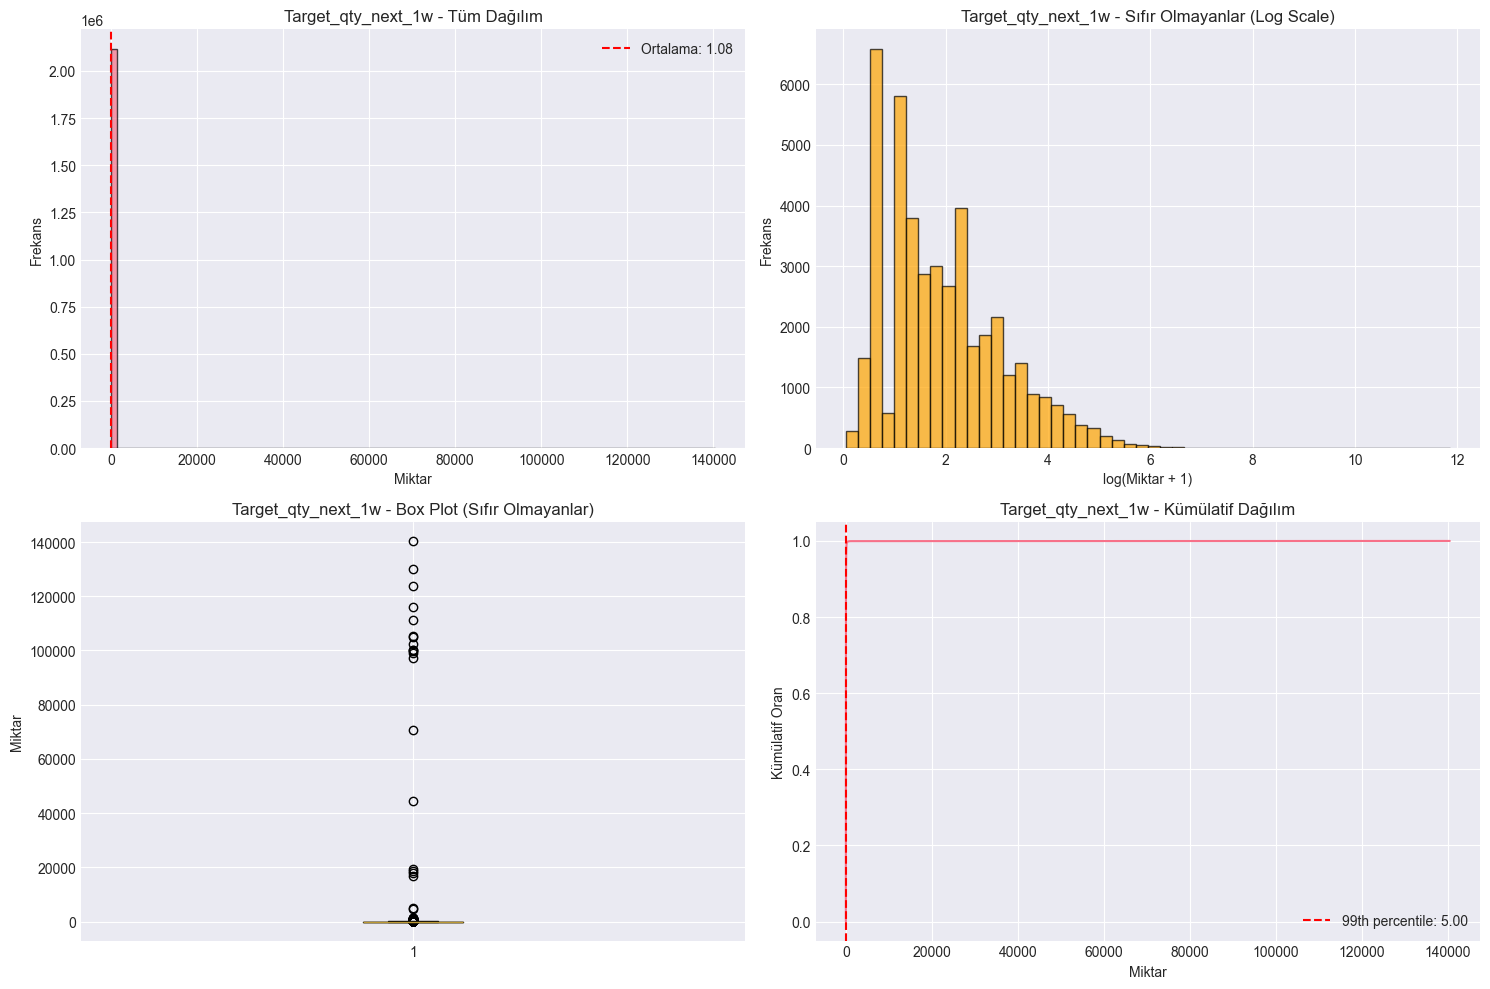

TARGET ANALİZİ: Target_qty_next_2w

📊 Temel İstatistikler:
  Toplam örnek: 2,114,436
  Sıfır: 2,055,832 (97.23%)
  Sıfır olmayan: 58,604 (2.77%)
  Ortalama: 2.2241
  Medyan: 0.0000
  Std: 476.7044
  Min: 0.00
  Max: 270400.00

📈 Percentile Dağılımı:
  50th percentile: 0.00
  75th percentile: 0.00
  90th percentile: 0.00
  95th percentile: 0.00
  99th percentile: 10.00
  99.5th percentile: 29.00
  99.9th percentile: 120.00

🎯 Sıfır Olmayan Değerler İçin:
  Ortalama: 80.2467
  Medyan: 6.0000
  Std: 2862.3354
  Min: 0.10
  Max: 270400.00

⚠️  Extreme Outlier'lar (99th percentile üstü):
  Threshold: 10.00
  Örnek sayısı: 20,646 (0.98%)
  Bu örneklerin ortalaması: 220.91
  Bu örneklerin max'ı: 270400.00


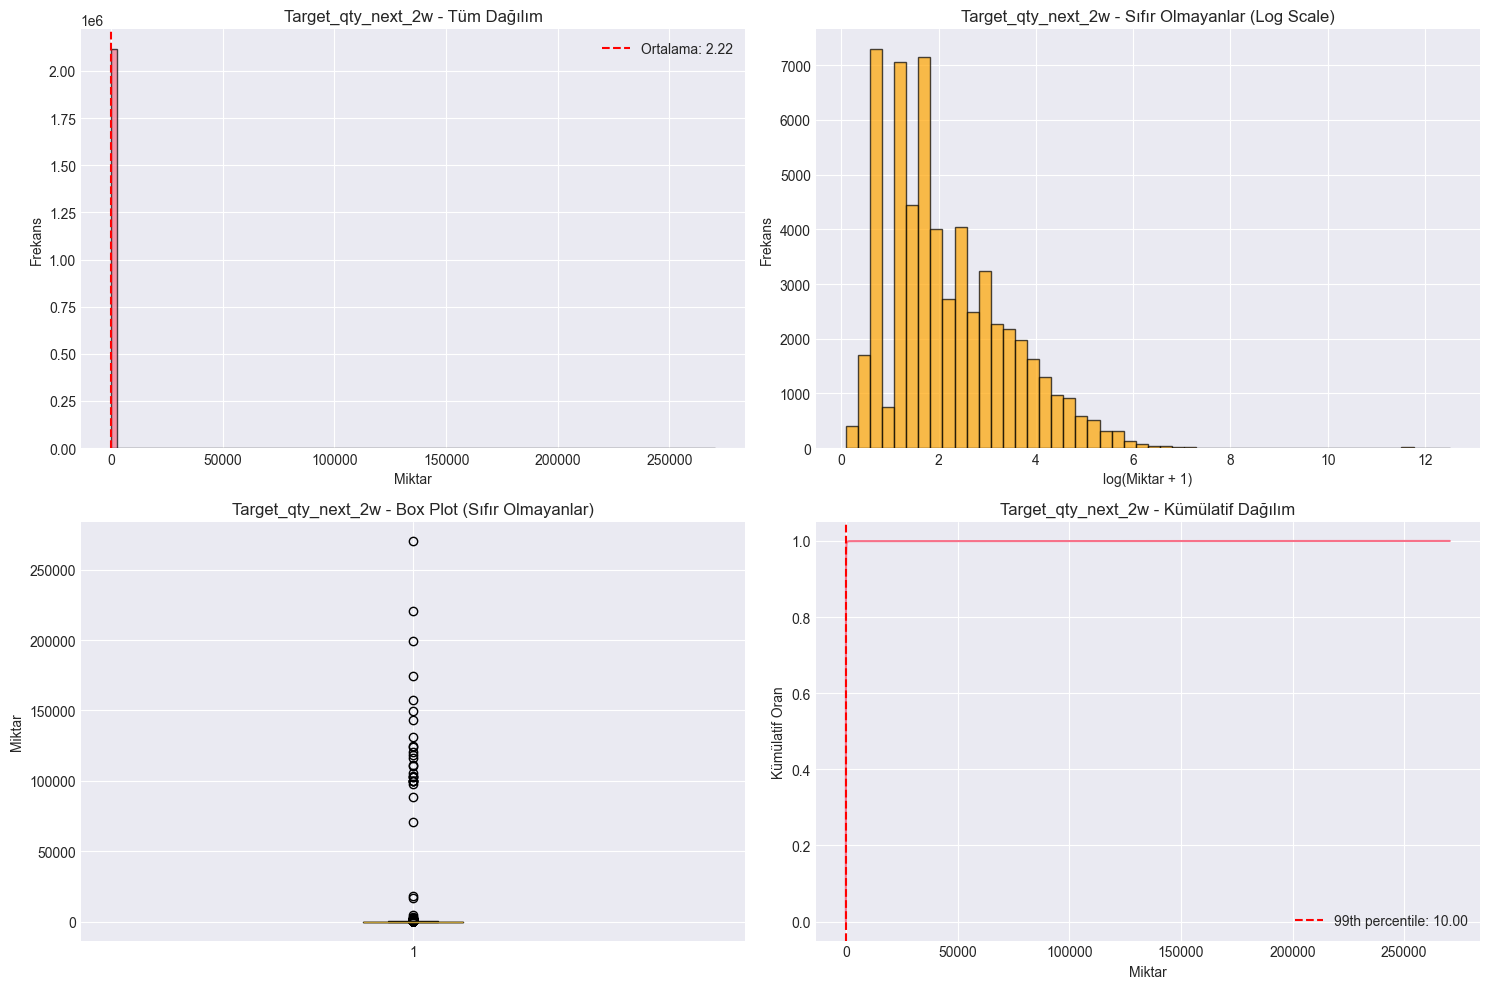

In [14]:
# ============================================================================
# TARGET ANALİZİ - Miktar Dağılımını Anla
# ============================================================================

def analyze_target_distribution(df, target_col):
    """
    Target'ın dağılımını detaylı analiz et
    """
    print("="*80)
    print(f"TARGET ANALİZİ: {target_col}")
    print("="*80)
    
    target = df[target_col].copy()
    
    # Temel istatistikler
    print(f"\n📊 Temel İstatistikler:")
    print(f"  Toplam örnek: {len(target):,}")
    print(f"  Sıfır: {(target == 0).sum():,} ({(target == 0).mean()*100:.2f}%)")
    print(f"  Sıfır olmayan: {(target > 0).sum():,} ({(target > 0).mean()*100:.2f}%)")
    print(f"  Ortalama: {target.mean():.4f}")
    print(f"  Medyan: {target.median():.4f}")
    print(f"  Std: {target.std():.4f}")
    print(f"  Min: {target.min():.2f}")
    print(f"  Max: {target.max():.2f}")
    
    # Percentile analizi
    print(f"\n📈 Percentile Dağılımı:")
    percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]
    for p in percentiles:
        val = target.quantile(p/100)
        print(f"  {p}th percentile: {val:.2f}")
    
    # Sıfır olmayan değerler için ayrı analiz
    non_zero = target[target > 0]
    if len(non_zero) > 0:
        print(f"\n🎯 Sıfır Olmayan Değerler İçin:")
        print(f"  Ortalama: {non_zero.mean():.4f}")
        print(f"  Medyan: {non_zero.median():.4f}")
        print(f"  Std: {non_zero.std():.4f}")
        print(f"  Min: {non_zero.min():.2f}")
        print(f"  Max: {non_zero.max():.2f}")
    
    # Extreme outlier'ları tespit et
    q99 = target.quantile(0.99)
    extreme_outliers = target[target > q99]
    print(f"\n⚠️  Extreme Outlier'lar (99th percentile üstü):")
    print(f"  Threshold: {q99:.2f}")
    print(f"  Örnek sayısı: {len(extreme_outliers):,} ({len(extreme_outliers)/len(target)*100:.2f}%)")
    print(f"  Bu örneklerin ortalaması: {extreme_outliers.mean():.2f}")
    print(f"  Bu örneklerin max'ı: {extreme_outliers.max():.2f}")
    
    # Görselleştirme
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Tüm dağılım (histogram)
    axes[0, 0].hist(target, bins=100, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'{target_col} - Tüm Dağılım')
    axes[0, 0].set_xlabel('Miktar')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].axvline(target.mean(), color='red', linestyle='--', label=f'Ortalama: {target.mean():.2f}')
    axes[0, 0].legend()
    
    # 2. Sıfır olmayan değerler (log scale)
    if len(non_zero) > 0:
        axes[0, 1].hist(np.log1p(non_zero), bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[0, 1].set_title(f'{target_col} - Sıfır Olmayanlar (Log Scale)')
        axes[0, 1].set_xlabel('log(Miktar + 1)')
        axes[0, 1].set_ylabel('Frekans')
    
    # 3. Box plot (outlier'ları göster)
    axes[1, 0].boxplot(target[target > 0], vert=True)
    axes[1, 0].set_title(f'{target_col} - Box Plot (Sıfır Olmayanlar)')
    axes[1, 0].set_ylabel('Miktar')
    
    # 4. Kümülatif dağılım
    sorted_target = np.sort(target[target > 0])
    cumulative = np.arange(1, len(sorted_target) + 1) / len(sorted_target)
    axes[1, 1].plot(sorted_target, cumulative)
    axes[1, 1].set_title(f'{target_col} - Kümülatif Dağılım')
    axes[1, 1].set_xlabel('Miktar')
    axes[1, 1].set_ylabel('Kümülatif Oran')
    axes[1, 1].axvline(q99, color='red', linestyle='--', label=f'99th percentile: {q99:.2f}')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'mean': target.mean(),
        'median': target.median(),
        'std': target.std(),
        'q99': q99,
        'non_zero_ratio': (target > 0).mean(),
        'extreme_outliers': len(extreme_outliers)
    }

# Her iki target için analiz
stats_1w = analyze_target_distribution(df_analysis, 'Target_qty_next_1w')
stats_2w = analyze_target_distribution(df_analysis, 'Target_qty_next_2w')

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [10]:
# ============================================================================
# ADIM 1: FEATURE ENGİNEERİNG (LAG FEATURES DAHİL)
# ============================================================================

def prepare_features_with_lags(df_):
    """
    Tüm feature engineering (lag'ler dahil)
    
    ÖNEMLİ: Bu fonksiyon train+val+test hepsine birlikte uygulanmalı!
    Çünkü lag'ler önceki haftalardan geliyor.
    """
    df = df_.copy()
    
    # Datetime'a çevir
    df['week_start'] = pd.to_datetime(df['week_start'])
    df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])
    
    # SIRALAMA (lag'ler için kritik!)
    df = df.sort_values(['customer_id', 'product_unit_variant_id', 'week_start']).reset_index(drop=True)
    
    print("\n--- FEATURE ENGINEERING (LAG'LER DAHİL) ---")
    
    # === ZAMAN FEATURELARI ===
    df['week'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)
    df['day_of_year'] = df['week_start'].dt.dayofyear.astype(int)
    
    print("  ✓ Zaman feature'ları oluşturuldu")
    
    # === MÜŞTERİ FEATURELARI ===
    df['customer_age_days'] = (df['week_start'] - df['customer_created_at']).dt.days.clip(lower=0).fillna(0).astype(int)
    
    print("  ✓ Müşteri feature'ları oluşturuldu")
    
    # === O HAFTANIN BİLGİLERİ ===
    if 'qty_this_week' not in df.columns:
        df['qty_this_week'] = 0
    if 'num_orders_week' not in df.columns: 
        df['num_orders_week'] = 0
    if 'spend_this_week' not in df.columns: 
        df['spend_this_week'] = 0
    if 'purchased_this_week' not in df.columns: 
        df['purchased_this_week'] = 0
        
    df['qty_this_week'] = df['qty_this_week'].fillna(0).astype(int)
    df['num_orders_week'] = df['num_orders_week'].fillna(0).astype(float)
    df['spend_this_week'] = df['spend_this_week'].fillna(0).astype(int)
    df['purchased_this_week'] = df['purchased_this_week'].fillna(0).astype(float)
    
    # =========================================================================
    # LAG FEATURES
    # =========================================================================
    group_key = ['customer_id', 'product_unit_variant_id']
    
    # === PURCHASED LAG'LERİ ===
    group_purchased = df.groupby(group_key)['purchased_this_week']
    
    df['purchased_lag_1'] = group_purchased.shift(1).fillna(0).astype(int)
    df['purchased_lag_2'] = group_purchased.shift(2).fillna(0).astype(int)
    df['purchased_lag_3'] = group_purchased.shift(3).fillna(0).astype(int)
    df['purchased_lag_4'] = group_purchased.shift(4).fillna(0).astype(int)
    
    print("  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchased_lag_4")
    
    # === ROLLING FEATURES ===
    df['roll_purchased_4_past'] = (
        df['purchased_lag_1'] + df['purchased_lag_2'] + 
        df['purchased_lag_3'] + df['purchased_lag_4']
    )
    
    print("  ✓ Rolling features: roll_purchased_4_past (son 4 hafta)")
    
    # === CUMULATIVE ===
    df['customer_purch_until_last_week'] = (
        df.groupby(group_key)['purchased_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )
    
    print("  ✓ Cumulative features: customer_purch_until_last_week")
    
    # === QUANTITY LAG'LERİ ===
    group_quantity = df.groupby(group_key)['qty_this_week']
    
    df['qty_lag_1'] = group_quantity.shift(1).fillna(0).astype(float)
    df['qty_lag_2'] = group_quantity.shift(2).fillna(0).astype(float)
    df['qty_lag_3'] = group_quantity.shift(3).fillna(0).astype(float)
    df['qty_lag_4'] = group_quantity.shift(4).fillna(0).astype(float)
    
    print("  ✓ Quantity lag features: qty_lag_1, qty_lag_2, qty_lag_3, qty_lag_4")
    
    # === QUANTITY ROLLING ===
    df['roll_quantity_4_past'] = (
        df['qty_lag_1'] + df['qty_lag_2'] + 
        df['qty_lag_3'] + df['qty_lag_4']
    )
    
    print("  ✓ Quantity rolling: roll_quantity_4_past")
    
    # === QUANTITY CUMULATIVE ===
    df['customer_quantity_until_last_week'] = (
        df.groupby(group_key)['qty_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )
    
    print("  ✓ Quantity cumulative: customer_quantity_until_last_week")
    
    # === BAŞKA ÜRÜNLERLE BİRLİKTE Mİ ALDI? ===
    df['purchased_with_other_products'] = (
        (df['purchased_this_week'] == 1) & (df['num_orders_week'] > 1)
    ).astype(int)
    
    df['purchased_with_others_lag_1'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(1).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_2'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(2).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_3'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(3).fillna(0).astype(int)
    )
    df['purchased_with_others_lag_4'] = (
        df.groupby(group_key)['purchased_with_other_products']
        .shift(4).fillna(0).astype(int)
    )
    
    print("  ✓ Birlikte alım features: purchased_with_others_lag_1, 2, 3, 4")
    
    # === RECENCY ===
    def weeks_since_last_purchase(group):
        """Her satır için son satın almadan bu yana geçen hafta sayısı"""
        result = []
        
        for i in range(len(group)):
            if i == 0:
                result.append(999)
            else:
                past_purchases = group.iloc[:i][group.iloc[:i]['purchased_this_week'] == 1]
                
                if len(past_purchases) == 0:
                    result.append(999)
                else:
                    last_purchase_week_idx = past_purchases.index[-1]
                    weeks_diff = i - (last_purchase_week_idx - group.index[0])
                    result.append(weeks_diff)
        
        return pd.Series(result, index=group.index)

    print("  → Son satın almadan bu yana geçen hafta hesaplanıyor...")
    df['weeks_since_last_purchase'] = (
        df.groupby(group_key, group_keys=False)
        .apply(weeks_since_last_purchase)
        .fillna(999)
        .astype(int)
    )
    
    print("  ✓ Recency feature: weeks_since_last_purchase")
    print(f"\n  Toplam feature sayısı: {len(df.columns)}")
        
    return df

In [11]:
# ============================================================================
# ADIM 2: TRAIN-VALIDATION-TEST SPLIT
# ============================================================================

def split_train_val_test(df, val_weeks=4, test_weeks=4):
    """
    Train-Validation-Test split (miktar tahmini için)
    
    Target'lar: Target_qty_next_1w, Target_qty_next_2w
    """
    
    df = df.copy()
    
    # Her iki quantity target'ı da olan satırları kullan
    df_with_target = df[
        df['Target_qty_next_1w'].notna() & 
        df['Target_qty_next_2w'].notna()
    ].copy()
    
    unique_weeks = np.sort(df_with_target['week_start'].unique())
    
    print("="*80)
    print("TRAIN-VALIDATION-TEST SPLIT (QUANTITY PREDICTION)")
    print("="*80)
    print(f"\nToplam hafta sayısı: {len(unique_weeks)}")
    print(f"İlk hafta: {unique_weeks[0]}")
    print(f"Son hafta: {unique_weeks[-1]}")
    
    # Cutoff'ları hesapla
    test_cutoff = unique_weeks[-test_weeks]
    val_cutoff = unique_weeks[-(test_weeks + val_weeks)]
    
    print(f"\nSplit stratejisi:")
    print(f"  Validation başlangıcı: {val_cutoff}")
    print(f"  Test başlangıcı: {test_cutoff}")
    
    # Maskeleri oluştur
    train_mask = df_with_target['week_start'] < val_cutoff
    val_mask = (df_with_target['week_start'] >= val_cutoff) & (df_with_target['week_start'] < test_cutoff)
    test_mask = df_with_target['week_start'] >= test_cutoff
    
    df_train = df_with_target[train_mask].copy()
    df_val = df_with_target[val_mask].copy()
    df_test = df_with_target[test_mask].copy()
    
    # İstatistikler
    print(f"\n{'='*80}")
    print("TRAIN SET:")
    print(f"  - Hafta sayısı: {len(df_train['week_start'].unique())}")
    print(f"  - Tarih aralığı: {df_train['week_start'].min()} → {df_train['week_start'].max()}")
    print(f"  - Satır sayısı: {len(df_train):,}")
    print(f"  - Oran: {len(df_train)/len(df_with_target)*100:.1f}%")
    print(f"  - Target 1w ortalama: {df_train['Target_qty_next_1w'].mean():.4f}")
    print(f"  - Target 2w ortalama: {df_train['Target_qty_next_2w'].mean():.4f}")
    
    print(f"\nVALIDATION SET:")
    print(f"  - Hafta sayısı: {len(df_val['week_start'].unique())}")
    print(f"  - Tarih aralığı: {df_val['week_start'].min()} → {df_val['week_start'].max()}")
    print(f"  - Satır sayısı: {len(df_val):,}")
    print(f"  - Oran: {len(df_val)/len(df_with_target)*100:.1f}%")
    print(f"  - Target 1w ortalama: {df_val['Target_qty_next_1w'].mean():.4f}")
    print(f"  - Target 2w ortalama: {df_val['Target_qty_next_2w'].mean():.4f}")
    
    print(f"\nTEST SET (Hold-out):")
    print(f"  - Hafta sayısı: {len(df_test['week_start'].unique())}")
    print(f"  - Tarih aralığı: {df_test['week_start'].min()} → {df_test['week_start'].max()}")
    print(f"  - Satır sayısı: {len(df_test):,}")
    print(f"  - Oran: {len(df_test)/len(df_with_target)*100:.1f}%")
    print(f"  - Target 1w ortalama: {df_test['Target_qty_next_1w'].mean():.4f}")
    print(f"  - Target 2w ortalama: {df_test['Target_qty_next_2w'].mean():.4f}")
    
    print(f"\n{'='*80}")
    
    return df_train, df_val, df_test

In [12]:
# ============================================================================
# ADIM 3: KATEGORİK ENCODE
# ============================================================================

def encode_categorical_features(df_train, df_val, df_test_holdout, df_test_real=None):
    """
    Kategorik değişkenleri encode et
    """
    
    # Düşük kardinalite → One-Hot
    low_cardinality_cols = ['customer_category', 'customer_status', 'grade_name', 'unit_name']
    low_cardinality_cols = [col for col in low_cardinality_cols if col in df_train.columns]
    
    # Yüksek kardinalite → Label Encoding
    high_cardinality_cols = ['customer_id', 'product_id']
    high_cardinality_cols = [col for col in high_cardinality_cols if col in df_train.columns]
    
    print("\n" + "="*80)
    print("ENCODING STRATEJİSİ")
    print("="*80)
    print(f"One-Hot Encoding: {low_cardinality_cols}")
    print(f"Label Encoding: {high_cardinality_cols}")
    
    # ONE-HOT ENCODING
    if low_cardinality_cols:
        print("\n--- ONE-HOT ENCODING ---")
        
        for col in low_cardinality_cols:
            unique_values = df_train[col].astype(str).unique()
            print(f"{col}: {len(unique_values)} değer")
            
            for val in unique_values:
                col_name = f"{col}_{val}"
                df_train[col_name] = (df_train[col].astype(str) == val).astype(int)
                df_val[col_name] = (df_val[col].astype(str) == val).astype(int)
                df_test_holdout[col_name] = (df_test_holdout[col].astype(str) == val).astype(int)
                
                if df_test_real is not None:
                    df_test_real[col_name] = (df_test_real[col].astype(str) == val).astype(int)
    
    # LABEL ENCODING
    encoders = {}
    
    if high_cardinality_cols:
        print("\n--- LABEL ENCODING ---")
        
        for col in high_cardinality_cols:
            encoder = LabelEncoder()
            encoder.fit(df_train[col].astype(str))
            
            print(f"{col}: {len(encoder.classes_)} değer")
            
            df_train[f'{col}_encoded'] = encoder.transform(df_train[col].astype(str))
            
            df_val[f'{col}_encoded'] = df_val[col].astype(str).map(
                lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1
            )
            
            df_test_holdout[f'{col}_encoded'] = df_test_holdout[col].astype(str).map(
                lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1
            )
            
            if df_test_real is not None:
                df_test_real[f'{col}_encoded'] = df_test_real[col].astype(str).map(
                    lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1
                )
            
            encoders[col] = encoder
    
    return df_train, df_val, df_test_holdout, df_test_real, encoders

In [13]:
# ============================================================================
# ADIM 4: MODEL EĞİTİMİ (REGRESSION)
# ============================================================================

def train_quantity_model(df_train, df_val, target_column, use_ridge=True, alpha=1.0):
    """
    Ridge/Linear Regression ile miktar tahmini
    
    Args:
        target_column: 'Target_qty_next_1w' veya 'Target_qty_next_2w'
        use_ridge: Ridge regression kullan (regularization)
        alpha: Ridge regularization strength
    """
    
    # Feature seçimi
    numeric_features = ['week','month','year','day_of_year','customer_age_days',
                       'purchased_lag_1', 'purchased_lag_2', 'purchased_lag_3', 'purchased_lag_4',
                       'roll_purchased_4_past','customer_purch_until_last_week',
                       'qty_lag_1','qty_lag_2','qty_lag_3','qty_lag_4',
                       'roll_quantity_4_past','customer_quantity_until_last_week',
                       'purchased_with_other_products','purchased_with_others_lag_1',
                       'purchased_with_others_lag_2','purchased_with_others_lag_3',
                       'purchased_with_others_lag_4','weeks_since_last_purchase']
    
    # One-hot ve label encoded sütunları ekle
    onehot_cols = [col for col in df_train.columns if any(
        col.startswith(f'{cat}_') for cat in ['customer_category', 'customer_status', 'grade_name', 'unit_name']
    )]
    
    label_encoded_cols = [col for col in df_train.columns if col.endswith('_encoded')]
    
    features = numeric_features + onehot_cols + label_encoded_cols
    features = [f for f in features if f in df_train.columns]
    
    print("\n" + "="*80)
    print(f"MODEL EĞİTİMİ (REGRESSION) - {target_column}")
    print("="*80)
    print(f"Feature sayısı: {len(features)}")
    print(f"  - Numeric: {len(numeric_features)}")
    print(f"  - One-Hot: {len(onehot_cols)}")
    print(f"  - Label Encoded: {len(label_encoded_cols)}")
    
    # Veri hazırlama
    X_train = df_train[features].fillna(0)
    y_train = df_train[target_column].fillna(0)
    
    X_val = df_val[features].fillna(0)
    y_val = df_val[target_column].fillna(0)
    
    print(f"\nTarget istatistikleri:")
    print(f"  Train - Ortalama: {y_train.mean():.4f}, Std: {y_train.std():.4f}, Max: {y_train.max():.0f}")
    print(f"  Val   - Ortalama: {y_val.mean():.4f}, Std: {y_val.std():.4f}, Max: {y_val.max():.0f}")
    print(f"  Train - Sıfır olmayan: {(y_train > 0).sum():,} / {len(y_train):,} ({(y_train > 0).mean()*100:.2f}%)")
    print(f"  Val   - Sıfır olmayan: {(y_val > 0).sum():,} / {len(y_val):,} ({(y_val > 0).mean()*100:.2f}%)")
    
    # Model
    if use_ridge:
        model = Ridge(alpha=alpha, random_state=42)
        print(f"\nRidge Regression kullanılıyor (alpha={alpha})")
    else:
        model = LinearRegression()
        print(f"\nLinear Regression kullanılıyor")
    
    print(f"Model eğitiliyor...")
    model.fit(X_train, y_train)
    
    # Tahminler
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Negatif tahminleri 0'a çek
    y_train_pred = np.maximum(y_train_pred, 0)
    y_val_pred = np.maximum(y_val_pred, 0)
    
    # Metrikler
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    print("\n" + "="*80)
    print("VALİDATİON SONUÇLARI")
    print("="*80)
    print(f"Train MAE:  {train_mae:.4f}")
    print(f"Val MAE:    {val_mae:.4f}")
    print(f"Fark:       {abs(train_mae - val_mae):.4f}")
    print()
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Val RMSE:   {val_rmse:.4f}")
    print()
    print(f"Train R²:   {train_r2:.4f}")
    print(f"Val R²:     {val_r2:.4f}")
    
    if abs(train_mae - val_mae) > 0.5:
        print("  ⚠️  Overfitting olabilir!")
    
    # Tahmin dağılımı
    print(f"\nValidation tahmin istatistikleri:")
    print(f"  Ortalama: {y_val_pred.mean():.4f}")
    print(f"  Std: {y_val_pred.std():.4f}")
    print(f"  Min: {y_val_pred.min():.4f}")
    print(f"  Max: {y_val_pred.max():.4f}")
    
    return model, features

In [14]:
# ============================================================================
# ADIM 5: TEST (HOLD-OUT) DEĞERLENDİRMESİ
# ============================================================================

def evaluate_quantity_on_test(df_test, model, features, target_column):
    """
    Hold-out test setinde final performansı ölç (MAE metriği)
    """
    
    print("\n" + "="*80)
    print(f"TEST DEĞERLENDİRMESİ (REGRESSION) - {target_column}")
    print("="*80)
    print("NOT: Bu skorlar validation'a overfitting'i kontrol eder")
    print("="*80)
    
    X_test = df_test[features].fillna(0)
    y_test = df_test[target_column].fillna(0)
    
    # Tahmin
    y_test_pred = model.predict(X_test)
    y_test_pred = np.maximum(y_test_pred, 0)  # Negatif tahminleri 0'a çek
    
    # Metrikler
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nTest MAE:  {test_mae:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R²:   {test_r2:.4f}")
    
    # Hata analizi
    errors = np.abs(y_test - y_test_pred)
    print(f"\nHata dağılımı:")
    print(f"  Ortalama hata: {errors.mean():.4f}")
    print(f"  Medyan hata: {np.median(errors):.4f}")
    print(f"  %95'lik hata: {np.percentile(errors, 95):.4f}")
    print(f"  Max hata: {errors.max():.4f}")
    
    # Sıfır olmayan tahminler için analiz
    non_zero_mask = y_test > 0
    if non_zero_mask.sum() > 0:
        non_zero_mae = mean_absolute_error(y_test[non_zero_mask], y_test_pred[non_zero_mask])
        print(f"\nSıfır olmayan gerçek değerler için MAE: {non_zero_mae:.4f}")
        print(f"  Örnek sayısı: {non_zero_mask.sum():,}")
    
    return test_mae

In [15]:
# ============================================================================
# ADIM 6: GERÇEK TEST (CANLI) TAHMİNİ
# ============================================================================

def predict_quantity_real_test(df_test_real, model, features):
    """
    Gerçek test seti için miktar tahmini
    """
    
    print("\n" + "="*80)
    print("GERÇEK TEST (CANLI) TAHMİNİ")
    print("="*80)
    
    X_test_real = df_test_real[features].fillna(0)
    
    # Tahmin
    predictions = model.predict(X_test_real)
    predictions = np.maximum(predictions, 0)  # Negatif tahminleri 0'a çek
    
    print(f"  Tahmin sayısı: {len(predictions):,}")
    print(f"  Ortalama tahmin: {predictions.mean():.4f}")
    print(f"  Std: {predictions.std():.4f}")
    print(f"  Min: {predictions.min():.4f}")
    print(f"  Max: {predictions.max():.4f}")
    print(f"  Sıfır olmayan tahmin: {(predictions > 0).sum():,} ({(predictions > 0).mean()*100:.2f}%)")
    
    return predictions

In [16]:
# ============================================================================
# ANA PİPELİNE
# ============================================================================

def main_quantity_pipeline(df_train_raw, df_test_real_raw, val_weeks=4, test_weeks=4, 
                           use_ridge=True, alpha=1.0):
    """
    Miktar tahmini pipeline:
    1. Feature engineering
    2. İki ayrı model eğit: 1w ve 2w miktar için
    3. Her ikisi için de tahmin üret
    """
    
    print("="*80)
    print("MİKTAR TAHMİN PİPELİNE (REGRESSION)")
    print("="*80)
    
    # 1. Feature Engineering
    print("\n[1/7] Feature Engineering...")
    df_train = prepare_features_with_lags(df_train_raw)
    df_test_real = prepare_features_with_lags(df_test_real_raw)
    
    # 2. Train-Val-Test Split
    print("\n[2/7] Train-Validation-Test Split...")
    df_train_split, df_val_split, df_test_holdout = split_train_val_test(
        df_train, val_weeks=val_weeks, test_weeks=test_weeks
    )
    
    # 3. Encoding
    print("\n[3/7] Kategorik encoding...")
    df_train_split, df_val_split, df_test_holdout, df_test_real, encoders = encode_categorical_features(
        df_train_split, df_val_split, df_test_holdout, df_test_real
    )
    
    # ==========================================================================
    # 1 HAFTA SONRASI MODELİ
    # ==========================================================================
    print("\n" + "="*80)
    print("1 HAFTA SONRASI MİKTAR TAHMİNİ (Target_qty_next_1w)")
    print("="*80)
    
    print("\n[4a/7] Model eğitimi (1w)...")
    model_1w, features_1w = train_quantity_model(
        df_train_split, df_val_split, 
        target_column='Target_qty_next_1w',
        use_ridge=use_ridge,
        alpha=alpha
    )
    
    print("\n[5a/7] Test değerlendirmesi (1w)...")
    test_mae_1w = evaluate_quantity_on_test(
        df_test_holdout, model_1w, features_1w,
        target_column='Target_qty_next_1w'
    )
    
    print("\n[6a/7] Gerçek test tahmini (1w)...")
    pred_qty_1w = predict_quantity_real_test(
        df_test_real, model_1w, features_1w
    )
    
    # ==========================================================================
    # 2 HAFTA SONRASI MODELİ
    # ==========================================================================
    print("\n" + "="*80)
    print("2 HAFTA SONRASI MİKTAR TAHMİNİ (Target_qty_next_2w)")
    print("="*80)
    
    print("\n[4b/7] Model eğitimi (2w)...")
    model_2w, features_2w = train_quantity_model(
        df_train_split, df_val_split,
        target_column='Target_qty_next_2w',
        use_ridge=use_ridge,
        alpha=alpha
    )
    
    print("\n[5b/7] Test değerlendirmesi (2w)...")
    test_mae_2w = evaluate_quantity_on_test(
        df_test_holdout, model_2w, features_2w,
        target_column='Target_qty_next_2w'
    )
    
    print("\n[6b/7] Gerçek test tahmini (2w)...")
    pred_qty_2w = predict_quantity_real_test(
        df_test_real, model_2w, features_2w
    )
    
    # ==========================================================================
    # SUBMİSSİON
    # ==========================================================================
    print("\n[7/7] Submission hazırlanıyor...")
    submission = pd.DataFrame({
        'ID': df_test_real['ID'],
        'Target_qty_next_1w': pred_qty_1w,
        'Target_qty_next_2w': pred_qty_2w
    })
    
    # ==========================================================================
    # ÖZET
    # ==========================================================================
    print("\n" + "="*80)
    print("ÖZET")
    print("="*80)
    print(f"1w Model (Miktar Tahmini):")
    print(f"  Test MAE: {test_mae_1w:.4f}")
    print(f"  Ortalama tahmin: {pred_qty_1w.mean():.4f}")
    print(f"  Sıfır olmayan tahmin: {(pred_qty_1w > 0).sum():,} ({(pred_qty_1w > 0).mean()*100:.2f}%)")
    
    print(f"\n2w Model (Miktar Tahmini):")
    print(f"  Test MAE: {test_mae_2w:.4f}")
    print(f"  Ortalama tahmin: {pred_qty_2w.mean():.4f}")
    print(f"  Sıfır olmayan tahmin: {(pred_qty_2w > 0).sum():,} ({(pred_qty_2w > 0).mean()*100:.2f}%)")
    
    print(f"\nSubmission hazır: {len(submission):,} satır")
    print(f"Sütunlar: {list(submission.columns)}")
    
    return {
        'model_1w': model_1w,
        'model_2w': model_2w,
        'features_1w': features_1w,
        'features_2w': features_2w,
        'submission': submission,
        'test_mae_1w': test_mae_1w,
        'test_mae_2w': test_mae_2w
    }

In [17]:
# ============================================================================
# KULLANIM
# ============================================================================

# Veriyi yükle
df_train_raw = pd.read_csv("../data/train.csv")
df_test_real_raw = pd.read_csv("../data/test.csv")

# Pipeline çalıştır
results = main_quantity_pipeline(
    df_train_raw, 
    df_test_real_raw,
    val_weeks=4,
    test_weeks=4,
    use_ridge=True,   # Ridge regression kullan (regularization)
    alpha=1.0         # Regularization strength (büyük = daha fazla)
)

# Submission kaydet
results['submission'].to_csv('submission_quantity.csv', index=False)

print("\n✅ Submission kaydedildi: submission_quantity.csv")
print(f"   Boyut: {len(results['submission']):,} satır x {len(results['submission'].columns)} sütun")

MİKTAR TAHMİN PİPELİNE (REGRESSION)

[1/7] Feature Engineering...

--- FEATURE ENGINEERING (LAG'LER DAHİL) ---
  ✓ Zaman feature'ları oluşturuldu
  ✓ Müşteri feature'ları oluşturuldu
  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchased_lag_4
  ✓ Rolling features: roll_purchased_4_past (son 4 hafta)
  ✓ Cumulative features: customer_purch_until_last_week
  ✓ Quantity lag features: qty_lag_1, qty_lag_2, qty_lag_3, qty_lag_4
  ✓ Quantity rolling: roll_quantity_4_past
  ✓ Quantity cumulative: customer_quantity_until_last_week
  ✓ Birlikte alım features: purchased_with_others_lag_1, 2, 3, 4
  → Son satın almadan bu yana geçen hafta hesaplanıyor...
  ✓ Recency feature: weeks_since_last_purchase

  Toplam feature sayısı: 43

--- FEATURE ENGINEERING (LAG'LER DAHİL) ---
  ✓ Zaman feature'ları oluşturuldu
  ✓ Müşteri feature'ları oluşturuldu
  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchased_lag_4
  ✓ Rolling features: roll_purchased_4_past (

In [ ]:
# ============================================================================
# BONUS: HYPERPARAMETER TUNING (Farklı alpha değerlerini dene)
# ============================================================================

# Farklı alpha değerlerini test et
alphas_to_try = [0.1, 0.5, 1.0, 5.0, 10.0]

best_alpha = None
best_mae = float('inf')

print("\n" + "="*80)
print("HYPERPARAMETER TUNING (ALPHA)")
print("="*80)

for alpha in alphas_to_try:
    print(f"\nDeneniyor: alpha={alpha}")
    
    results_temp = main_quantity_pipeline(
        df_train_raw, 
        df_test_real_raw,
        val_weeks=4,
        test_weeks=4,
        use_ridge=True,
        alpha=alpha
    )
    
    # 1w ve 2w MAE'lerinin ortalaması
    avg_mae = (results_temp['test_mae_1w'] + results_temp['test_mae_2w']) / 2
    
    print(f"  → Ortalama Test MAE: {avg_mae:.4f}")
    
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_alpha = alpha
        print(f"  ✓ Yeni en iyi!")

print("\n" + "="*80)
print(f"En iyi alpha: {best_alpha}")
print(f"En iyi ortalama MAE: {best_mae:.4f}")
print("="*80)




HYPERPARAMETER TUNING (ALPHA)

Deneniyor: alpha=0.1
MİKTAR TAHMİN PİPELİNE (REGRESSION)

[1/7] Feature Engineering...

--- FEATURE ENGINEERING (LAG'LER DAHİL) ---
  ✓ Zaman feature'ları oluşturuldu
  ✓ Müşteri feature'ları oluşturuldu
  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchased_lag_4
  ✓ Rolling features: roll_purchased_4_past (son 4 hafta)
  ✓ Cumulative features: customer_purch_until_last_week
  ✓ Quantity lag features: qty_lag_1, qty_lag_2, qty_lag_3, qty_lag_4
  ✓ Quantity rolling: roll_quantity_4_past
  ✓ Quantity cumulative: customer_quantity_until_last_week
  ✓ Birlikte alım features: purchased_with_others_lag_1, 2, 3, 4
  → Son satın almadan bu yana geçen hafta hesaplanıyor...
  ✓ Recency feature: weeks_since_last_purchase

  Toplam feature sayısı: 43

--- FEATURE ENGINEERING (LAG'LER DAHİL) ---
  ✓ Zaman feature'ları oluşturuldu
  ✓ Müşteri feature'ları oluşturuldu
  ✓ Lag features: purchased_lag_1, purchased_lag_2, purchased_lag_3, purchase